<a href="https://colab.research.google.com/github/Leeraaa/Data-Science-Project/blob/main/Data-Science-Seasonal-Temperature-Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project: Time Series Forecasting


## Введение

Этот проект посвящен анализу временного ряда температуры (`temp_max`) и прогнозированию будущих значений с использованием различных методов.
Мы применим следующие модели:
- **ARIMA** – базовая временная модель.
- **SARIMA** – улучшенная версия ARIMA с учетом сезонности.
- **Prophet** – мощная модель от Facebook, учитывающая тренды, сезонность и праздничные дни.

Оценка моделей будет проводиться с помощью метрик: MSE, RMSE, MAE.


#Dataset

In [ ]:
from google.colab import files
import pandas as pd

# Загружаем файл
uploaded = files.upload()

# Читаем CSV-файл (замени 'seattle-weather.csv' на имя загруженного файла)
file_name = "weather.csv"
df = pd.read_csv(file_name)

Saving weather.csv to weather (5).csv


In [ ]:
# Просмотр первых строк
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


## 1. Загрузка и исследование данных

In [ ]:
# Размер датасета
df.shape

(1461, 6)

## 1. Загрузка и исследование данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
df.describe(include ="all")

,date,precipitation,temp_max,temp_min,wind,weather
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461
unique,1461,NaN,NaN,NaN,NaN,5
top,2012-01-01,NaN,NaN,NaN,NaN,rain
freq,1,NaN,NaN,NaN,NaN,641
mean,NaN,3.029432,16.439083,8.234771,3.241136,NaN
std,NaN,6.680194,7.349758,5.023004,1.437825,NaN
min,NaN,0.000000,-1.600000,-7.100000,0.400000,NaN
25%,NaN,0.000000,10.600000,4.400000,2.200000,NaN
50%,NaN,0.000000,15.600000,8.300000,3.000000,NaN
75%,NaN,2.800000,22.200000,12.200000,4.000000,NaN


# Cleaning

In [ ]:
# Проверка пропущенных значений
df.isna().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


In [ ]:
# Проверка дубликатов
print(df.duplicated().sum())

0


In [ ]:
# Подсчитать количество пропусков в каждом столбце
print(df.isna().sum())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [ ]:
df.nunique()

,0
date,1461
precipitation,111
temp_max,67
temp_min,55
wind,79
weather,5


In [ ]:
df['weather'].value_counts()

,count
weather,
rain,641
sun,640
fog,101
drizzle,53
snow,26


In [ ]:
df['precipitation'].unique()

array([ 0. , 10.9,  0.8, 20.3,  1.3,  2.5,  4.3,  1. ,  4.1,  5.3,  8.1,
       19.8, 15.2, 13.5,  3. ,  6.1,  8.6,  4.8, 27.7,  3.6,  1.8,  0.3,
        2.8, 11.4, 17.3,  6.4,  2. ,  6.9,  0.5, 10.4, 13.7, 19.3,  9.4,
       23.9,  8.4, 27.4,  5.6, 13.2,  1.5,  4.6,  2.3,  6.6, 10.7,  3.8,
       18.5, 14. , 16. , 16.5, 15.7,  5.8,  7.9, 20.8,  8.9,  7.1, 23.1,
       34.5, 14.5,  9.7, 54.1, 11.2, 32. , 35.6, 19.6, 13. , 14.2, 22.6,
        3.3, 16.3, 38.4,  5.1, 11.9,  7.4, 11.7,  9.9, 12.7, 39.1, 20.6,
       21.3, 43.4, 16.8,  9.1, 30. , 26.2, 12.2, 21.6, 18.3, 17. , 26.4,
       19.1, 46.7, 32.3, 18.8, 22.1, 12.4, 33.3,  7.6, 15. , 25.4, 34.3,
       10.2, 23.6, 55.9, 30.5, 32.5, 28.7, 33. , 33.5, 47.2, 22.4, 29.5,
       21.8])

In [ ]:
df['temp_max'].unique()

array([12.8, 10.6, 11.7, 12.2,  8.9,  4.4,  7.2, 10. ,  9.4,  6.1,  5. ,
        1.1,  1.7,  3.3,  0. , -1.1,  8.3,  6.7, 14.4, 15.6, 13.9, 16.1,
       11.1,  7.8,  5.6, 15. , 13.3, 16.7, 21.1, 20. , 17.8, 23.3, 21.7,
       23.9, 18.3, 24.4, 25.6, 26.7, 19.4, 17.2, 22.2, 18.9, 22.8, 20.6,
       25. , 28.3, 27.8, 26.1, 27.2, 33.9, 30.6, 28.9, 31.1, 34.4, 32.8,
       32.2,  3.9,  2.8,  2.2, 30. , 31.7, -0.5, -1.6, 29.4, 35.6, 33.3,
       35. ])

In [ ]:
df['temp_min'].unique()

array([ 5. ,  2.8,  7.2,  5.6,  2.2,  0.6, -1.1, -1.7, -2.8, -3.3,  0. ,
        3.3,  1.1,  4.4, -2.2,  3.9,  6.1,  1.7,  7.8,  6.7, -0.6,  8.9,
        8.3, 10. ,  9.4, 12.8, 11.7, 11.1, 12.2, 10.6, 15. , 13.3, 14.4,
       13.9, 16.7, 17.8, 15.6, 18.3, 16.1, -3.9, -4.4, 17.2, -0.5, -2.1,
       -4.9, -4.3, -7.1, -6.6, -1.6, -5.5, -6. , -3.2, -2.7, -1. , -3.8])

In [ ]:
df['wind'].unique()

array([4.7, 4.5, 2.3, 6.1, 2.2, 2. , 3.4, 5.1, 1.9, 1.3, 5.3, 3.2, 5. ,
       5.6, 1.6, 8.2, 4.8, 3.6, 5.4, 1.4, 3.9, 2.7, 2.6, 4.3, 2.9, 2.4,
       3. , 3.1, 1.8, 2.1, 8.1, 7.5, 5.9, 3.5, 6.4, 4.2, 7. , 6.2, 2.5,
       2.8, 5.8, 3.8, 5.2, 4.4, 6.8, 4.1, 4. , 8. , 4.6, 1.5, 6.3, 3.3,
       3.7, 1.7, 6. , 1.1, 7.3, 6.5, 5.7, 5.5, 4.9, 1. , 1.2, 9.5, 0.6,
       7.1, 7.6, 0.9, 0.4, 7.9, 7.2, 0.5, 0.7, 8.8, 0.8, 6.6, 6.9, 6.7,
       7.7])

*Данные содержат следующие переменные:*

precipitation — осадки (мм).

temp_max — максимальная температура (°C).

temp_min — минимальная температура (°C).

wind — скорость ветра (м/с).

weather — категориальная переменная, описывающая погодные условия (дождь, морось и т. д.).

In [ ]:
# Установка date как индекса
df.set_index("date", inplace=True)
print(df.index)

Index(['2012-01-01', '2012-01-02', '2012-01-03', '2012-01-04', '2012-01-05',
       '2012-01-06', '2012-01-07', '2012-01-08', '2012-01-09', '2012-01-10',
       ...
       '2015-12-22', '2015-12-23', '2015-12-24', '2015-12-25', '2015-12-26',
       '2015-12-27', '2015-12-28', '2015-12-29', '2015-12-30', '2015-12-31'],
      dtype='object', name='date', length=1461)


# Charts

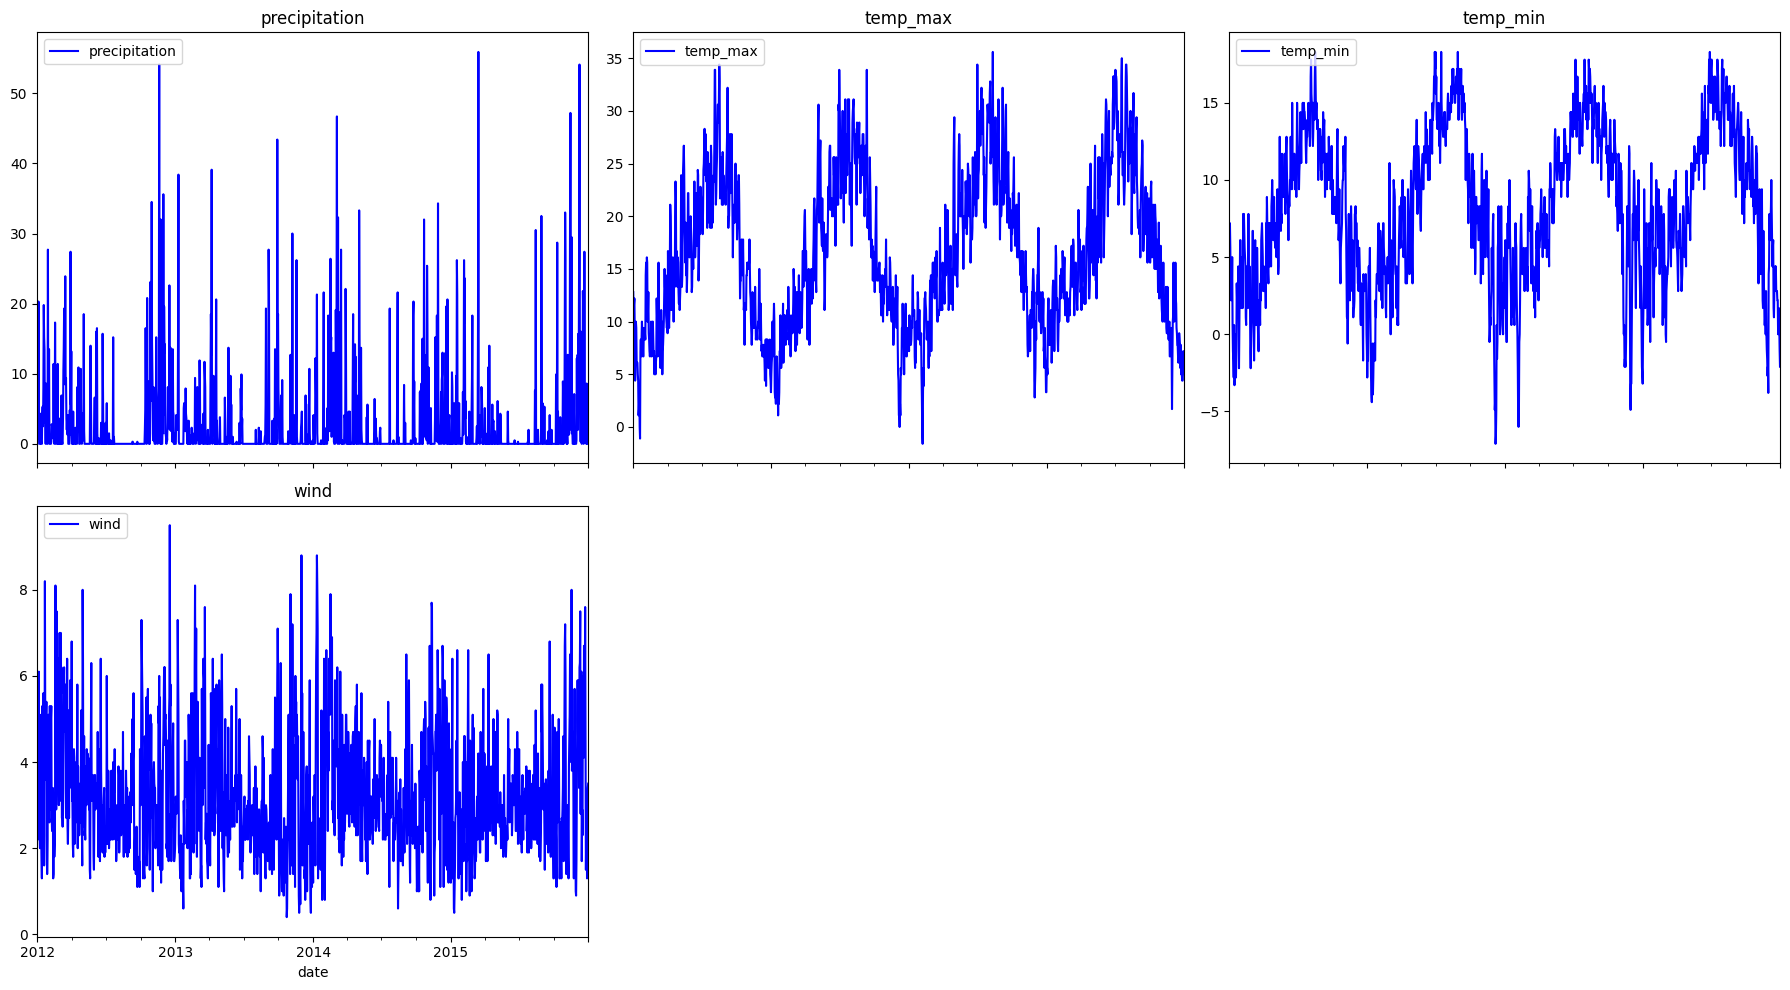

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Преобразуем дату в формат datetime
df.index = pd.to_datetime(df.index)

# Оставляем только числовые столбцы
numeric_cols = df.select_dtypes(include=['number']).columns

# Определяем количество строк и столбцов для сетки графиков
num_cols = 3  # 3 графика в строке
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols  # Рассчитываем строки

# Создаём сетку графиков
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows), sharex=True)

# Убедимся, что axes – это массив (даже если один ряд)
axes = axes.flatten()

# Строим графики
for i, col in enumerate(numeric_cols):
    df[col].plot(ax=axes[i], color='blue', title=col)
    axes[i].legend([col], loc=2)

# Удаляем лишние пустые графики (если их больше, чем данных)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Уплотняем макет и показываем графики
plt.tight_layout()
plt.show()

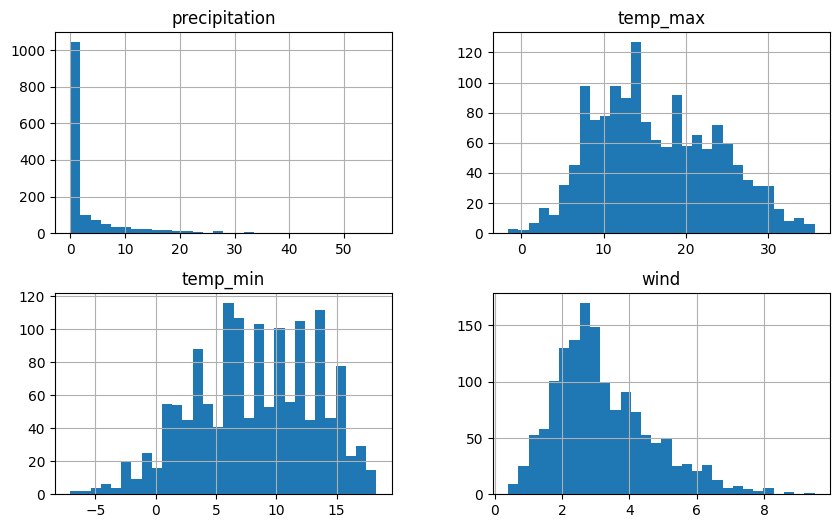

In [ ]:
# Визуальная проверка выбросов
import matplotlib.pyplot as plt

df[['precipitation', 'temp_max', 'temp_min', 'wind']].hist(figsize=(10, 6), bins=30)
plt.show()

## 2. Корреляционный анализ

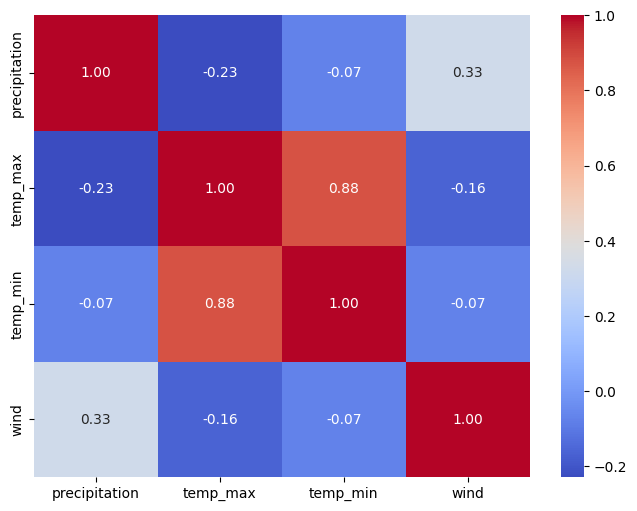

In [ ]:
# Проверка корреляции переменных
import seaborn as sns

# Оставляем только числовые столбцы
numeric_df = df.select_dtypes(include=['number'])

# Построение корреляционной матрицы
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


## 3. Определение параметров ARIMA/SARIMA

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Добавляем столбцы года и месяца для анализа сезонности
df['month'] = df.index.month
df['year'] = df.index.year

<ipython-input-21-248005f0bcec>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='temp_max', data=df, palette="coolwarm")


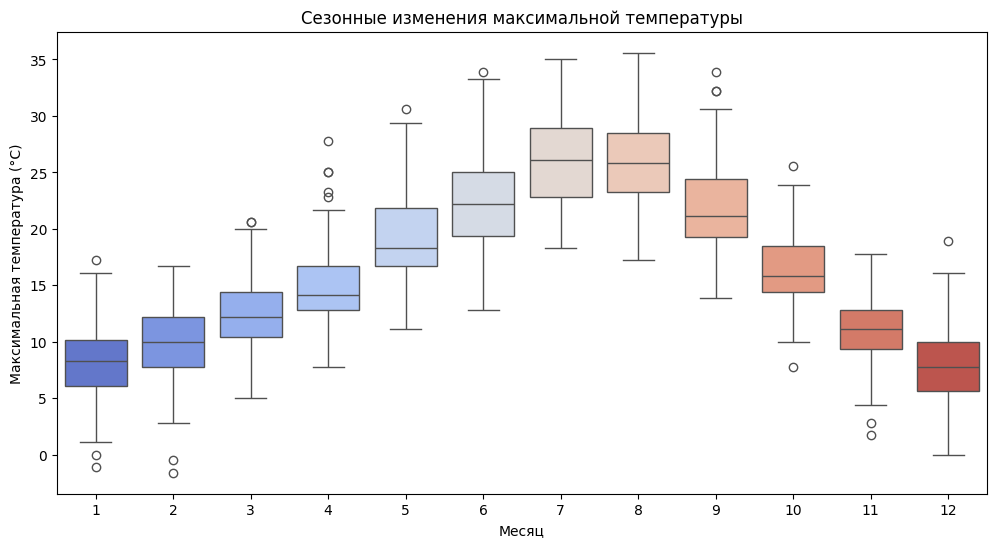

In [ ]:
# 1️⃣ Boxplot по месяцам (сезонность)
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='temp_max', data=df, palette="coolwarm")
plt.title("Сезонные изменения максимальной температуры")
plt.xlabel("Месяц")
plt.ylabel("Максимальная температура (°C)")
plt.show()

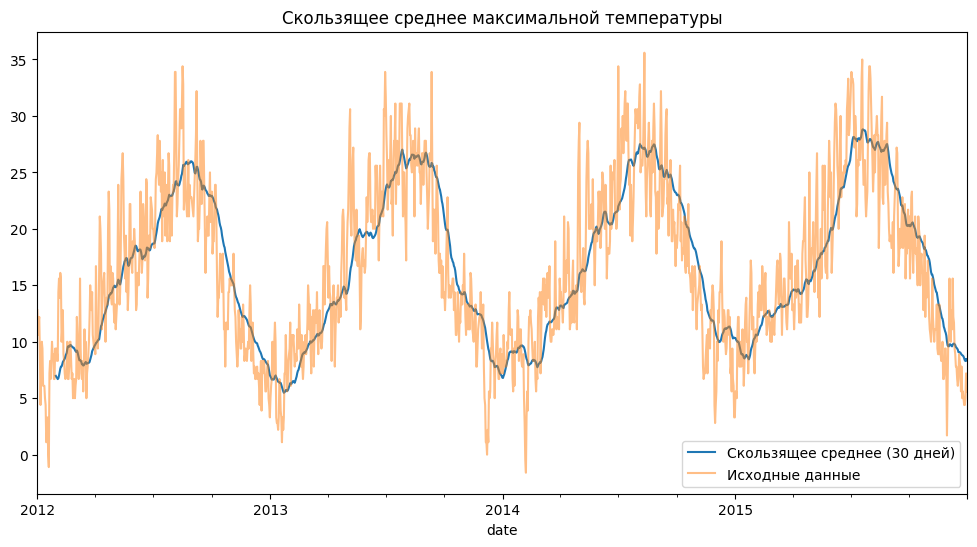

In [ ]:
# 2️⃣ Скользящее среднее (30 дней)
plt.figure(figsize=(12, 6))
df['temp_max'].rolling(window=30).mean().plot(label='Скользящее среднее (30 дней)')
df['temp_max'].plot(alpha=0.5, label='Исходные данные')
plt.legend()
plt.title("Скользящее среднее максимальной температуры")
plt.show()

## 3. Определение параметров ARIMA/SARIMA

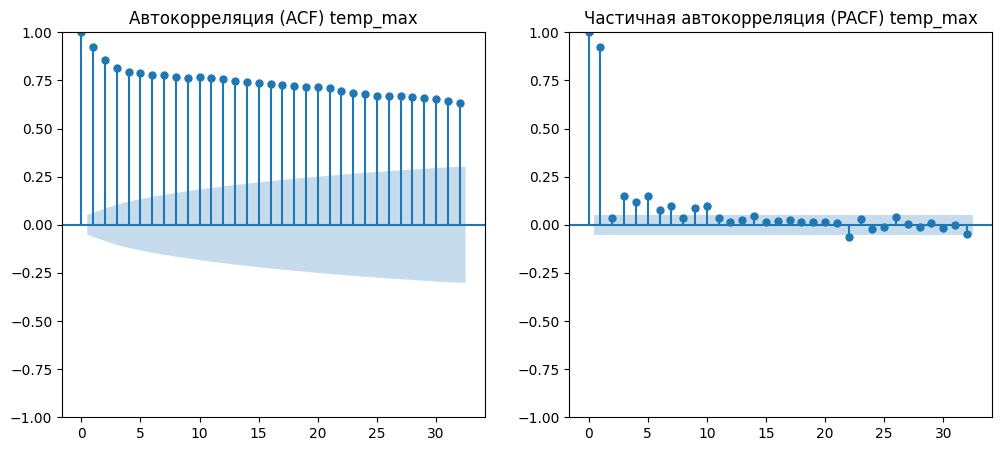

In [ ]:
# 3️⃣ ACF и PACF (для ARIMA-модели)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df['temp_max'].dropna(), ax=axes[0])
axes[0].set_title("Автокорреляция (ACF) temp_max")
plot_pacf(df['temp_max'].dropna(), ax=axes[1])
axes[1].set_title("Частичная автокорреляция (PACF) temp_max")
plt.show()


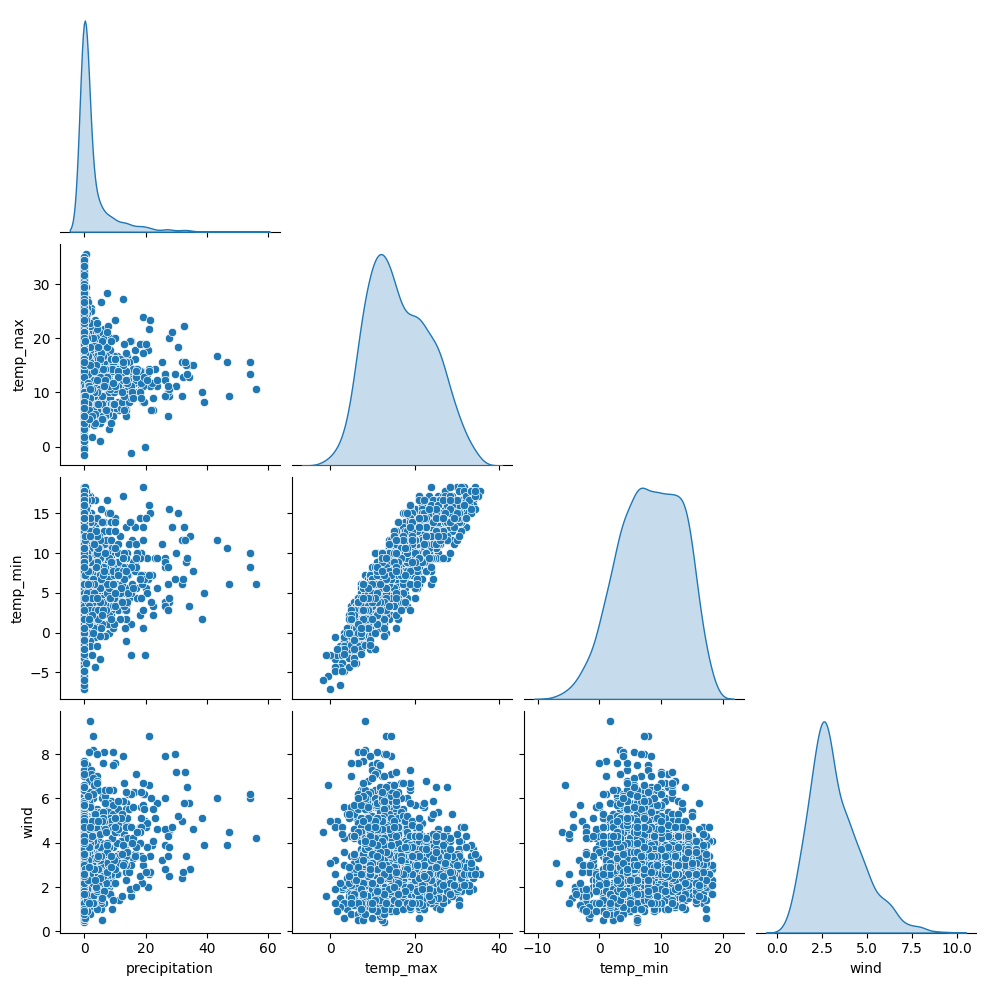

In [ ]:
# 4️⃣ Pairplot (взаимосвязь переменных)
sns.pairplot(df[['precipitation', 'temp_max', 'temp_min', 'wind']], diag_kind='kde', corner=True)
plt.show()

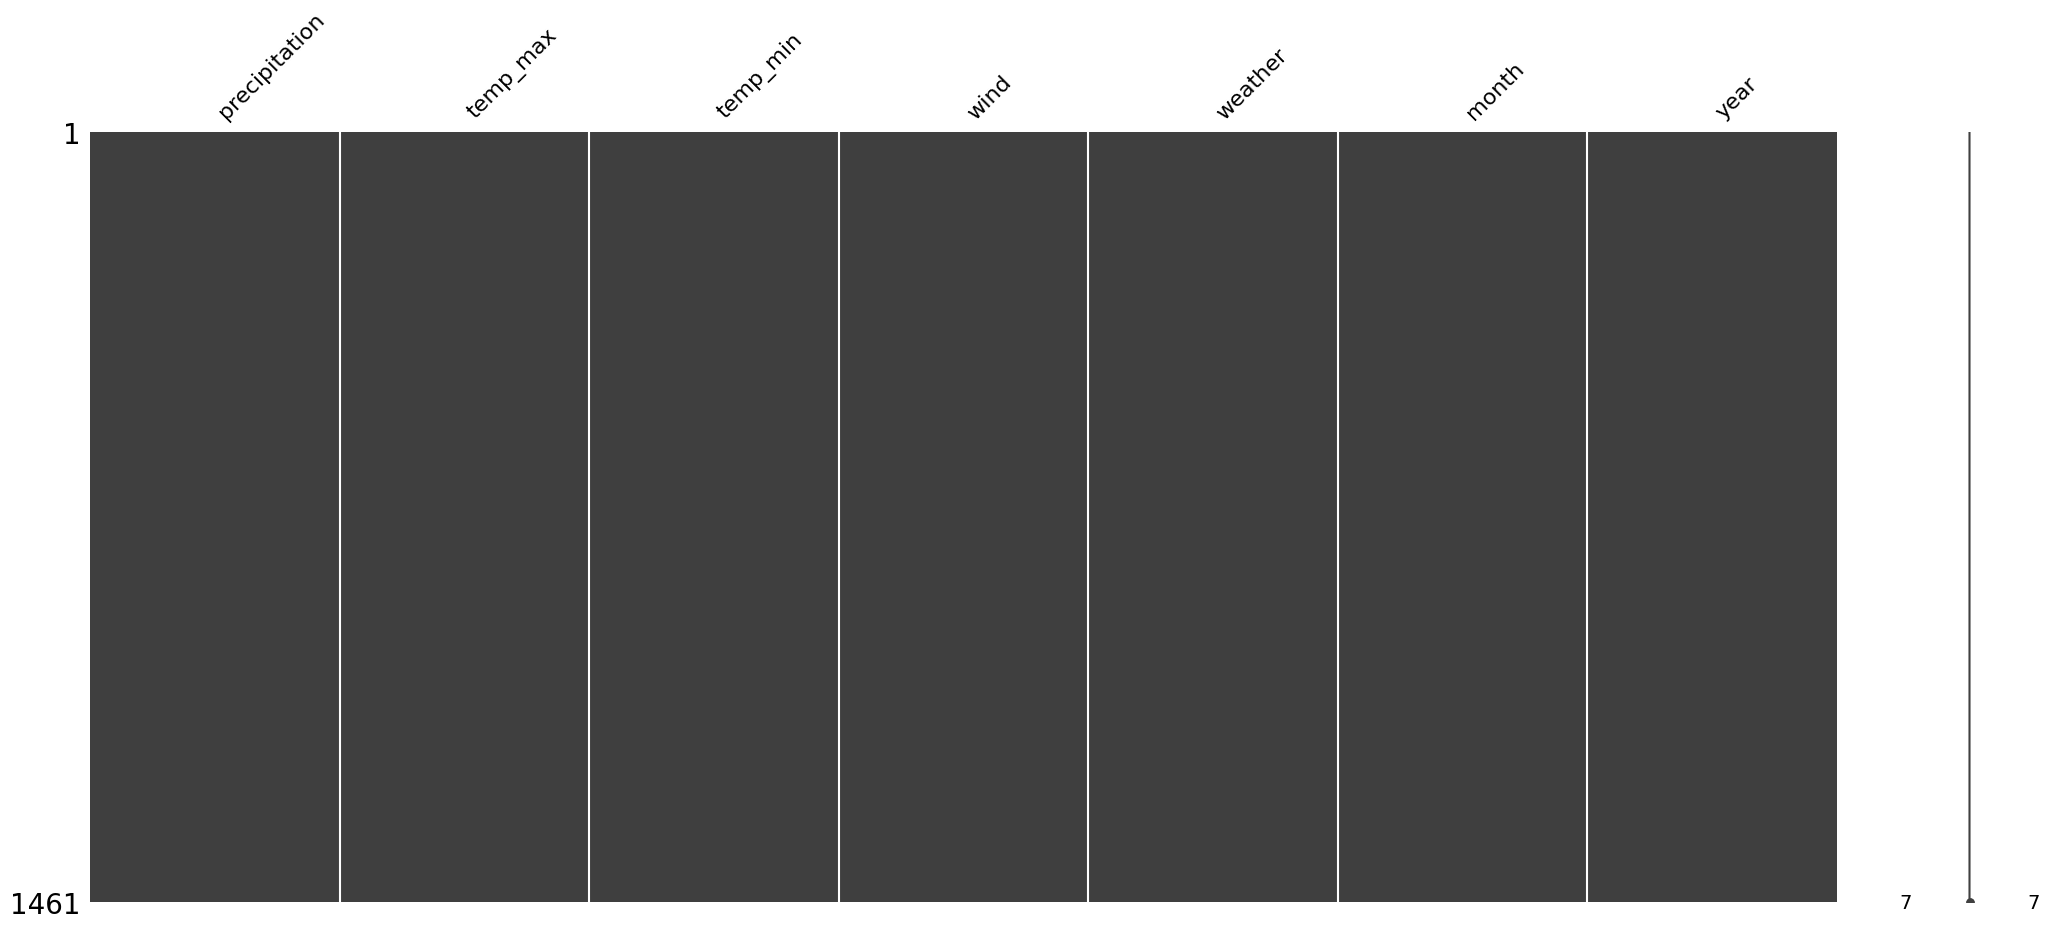

In [ ]:
# Heatmap пропущенных значений, чтобы убедиться, что нет скрытых проблем
import missingno as msno
msno.matrix(df)
plt.show()


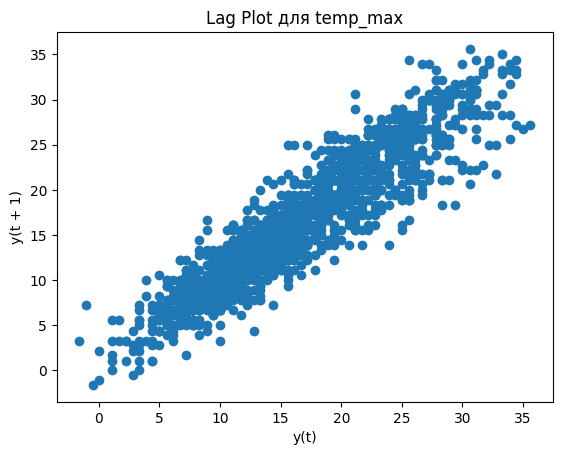

In [ ]:
# Lag plot для проверки зависимости данных от предыдущих значений
from pandas.plotting import lag_plot
lag_plot(df['temp_max'])
plt.title("Lag Plot для temp_max")
plt.show()


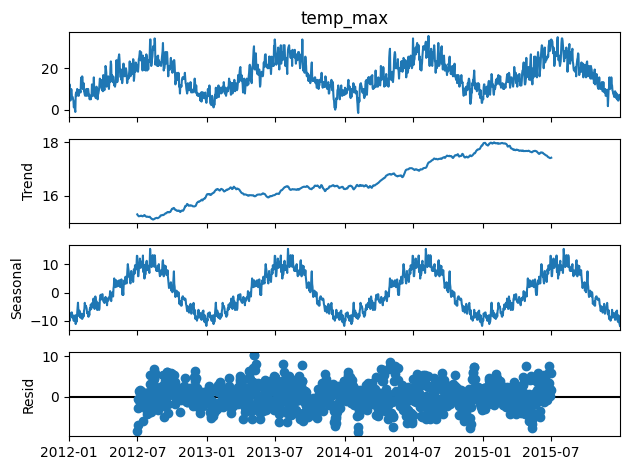

In [ ]:
# Seasonal Decomposition (разложение временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['temp_max'], model='additive', period=365)
result.plot()
plt.show()


In [ ]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df[['precipitation', 'temp_max', 'temp_min', 'wind']]))
print((z_scores > 3).sum(axis=0))  # Количество выбросов в каждом столбце


precipitation    37
temp_max          0
temp_min          1
wind             15
dtype: int64


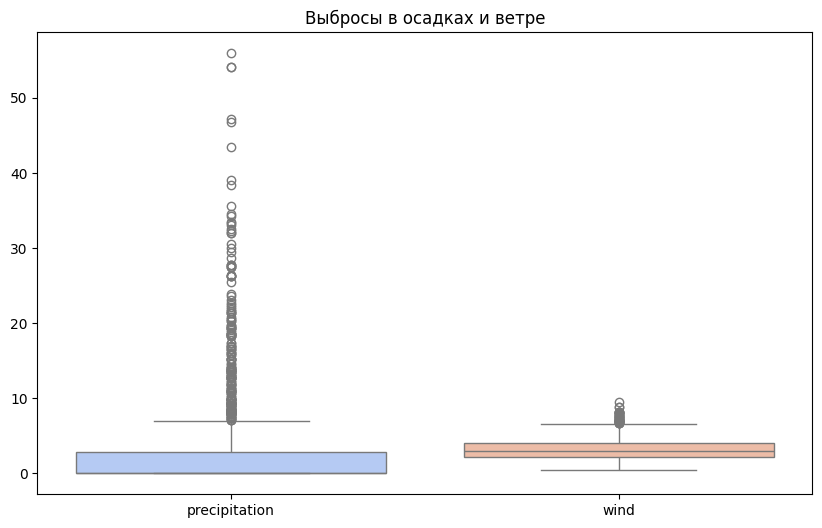

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['precipitation', 'wind']], palette="coolwarm")
plt.title("Выбросы в осадках и ветре")
plt.show()


# Кодирование данных

In [ ]:
# Кодирование weather
# Сначала преобразуем 'weather' в категорию
df['weather'] = df['weather'].astype('category')

# Создаем словарь кодов и их оригинальных значений
weather_mapping = dict(enumerate(df['weather'].cat.categories))

# Выводим соответствие кодов и оригинальных значений
for code, weather in weather_mapping.items():
    print(f"Код {code} → {weather}")

# Теперь заменяем текстовые значения 'weather' на числовые коды
df['weather'] = df['weather'].cat.codes


Код 0 → drizzle
Код 1 → fog
Код 2 → rain
Код 3 → snow
Код 4 → sun


# Feature Engineering (создание новых признаков)

In [ ]:
# разницу между temp_max и temp_min
df['temp_range'] = df['temp_max'] - df['temp_min']


In [ ]:
# скользящее среднее (например, для wind и precipitation
df['precipitation_rolling'] = df['precipitation'].rolling(window=7).mean()

# проверка стационарности (ADF test)

## 3. Определение параметров ARIMA/SARIMA

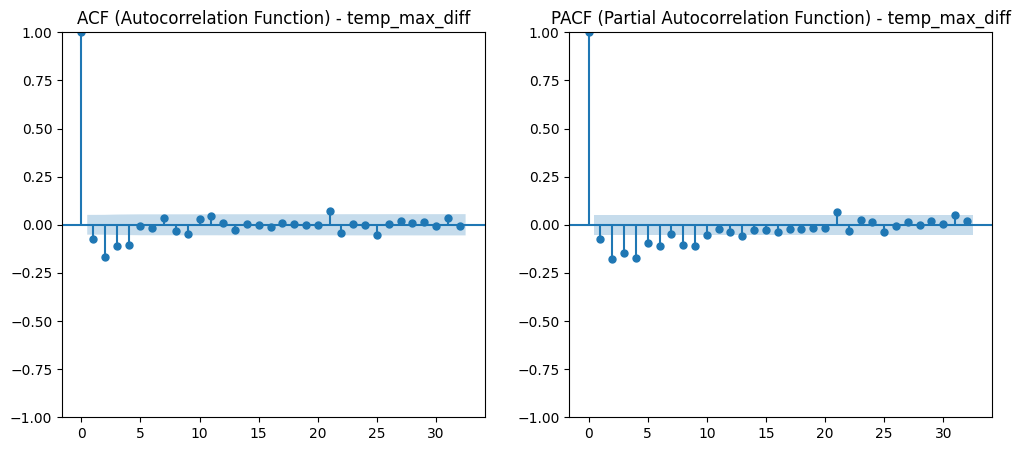

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Пересчитываем разности, если их нет
if 'temp_max_diff' not in df.columns:
    df['temp_max_diff'] = df['temp_max'].diff()
    df.dropna(inplace=True)

# Построение ACF и PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF (определяет q)
plot_acf(df['temp_max_diff'], ax=axes[0])
axes[0].set_title("ACF (Autocorrelation Function) - temp_max_diff")

# PACF (определяет p)
plot_pacf(df['temp_max_diff'], ax=axes[1])
axes[1].set_title("PACF (Partial Autocorrelation Function) - temp_max_diff")

plt.show()

# обучение ARIMA

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Дополнительное дифференцирование для получения стационарности
df['temp_max_diff'] = df['temp_max'].diff().dropna()

# Проверка на стационарность после дополнительного дифференцирования
adf_result_diff = adfuller(df['temp_max_diff'].dropna())
print("p-value после дифференцирования:", adf_result_diff[1])  # p-value, если < 0.05, данные стационарны


p-value после дифференцирования: 1.4911999102590859e-28


## 4. Обучение модели ARIMA и прогнозирование

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:               temp_max   No. Observations:                 1455
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3516.907
Date:                Tue, 11 Feb 2025   AIC                           7039.815
Time:                        12:43:12   BIC                           7055.661
Sample:                    01-07-2012   HQIC                          7045.727
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6271      0.032     19.715      0.000       0.565       0.689
ma.L1         -0.9027      0.019    -47.799      0.000      -0.940      -0.866
sigma2         7.3841      0.250     29.487      0.0

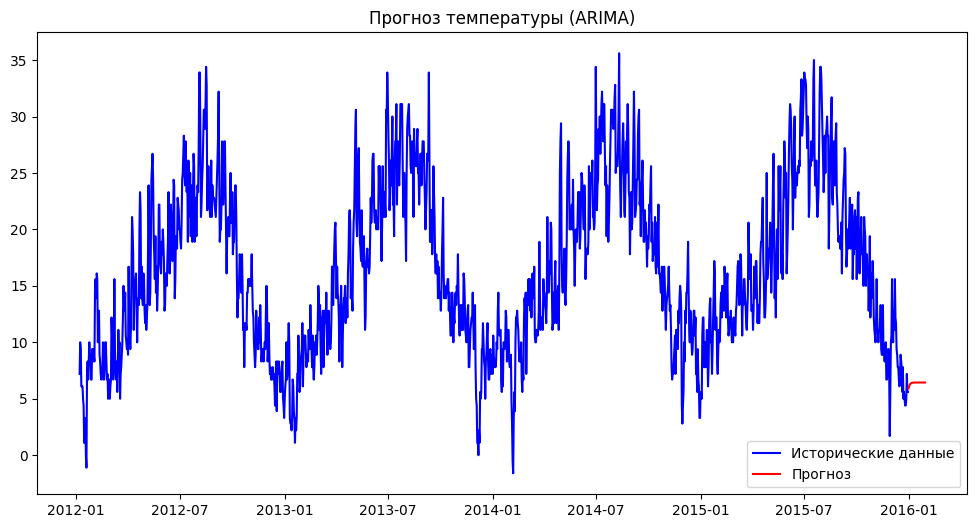

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Определенные параметры ARIMA
p, d, q = 1, 1, 1  # Или p=1, d=1, q=2

# Обучение модели ARIMA на temp_max
model = ARIMA(df['temp_max'], order=(p, d, q))
model_fit = model.fit()

# Вывод параметров модели
print(model_fit.summary())

# Прогноз на 30 дней вперед
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Визуализация прогноза
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps+1, freq="D")[1:], forecast, label="Прогноз", color="red")
plt.title("Прогноз температуры (ARIMA)")
plt.legend()
plt.show()

## 4. Обучение модели ARIMA и прогнозирование

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               temp_max   No. Observations:                 1455
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -3505.562
Date:                Tue, 11 Feb 2025   AIC                           7019.124
Time:                        12:43:14   BIC                           7040.252
Sample:                    01-07-2012   HQIC                          7027.007
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4815      0.052      9.217      0.000       0.379       0.584
ma.L1         -0.6853      0.056    -12.318      0.000      -0.794      -0.576
ma.L2         -0.1776      0.038     -4.654      0.0

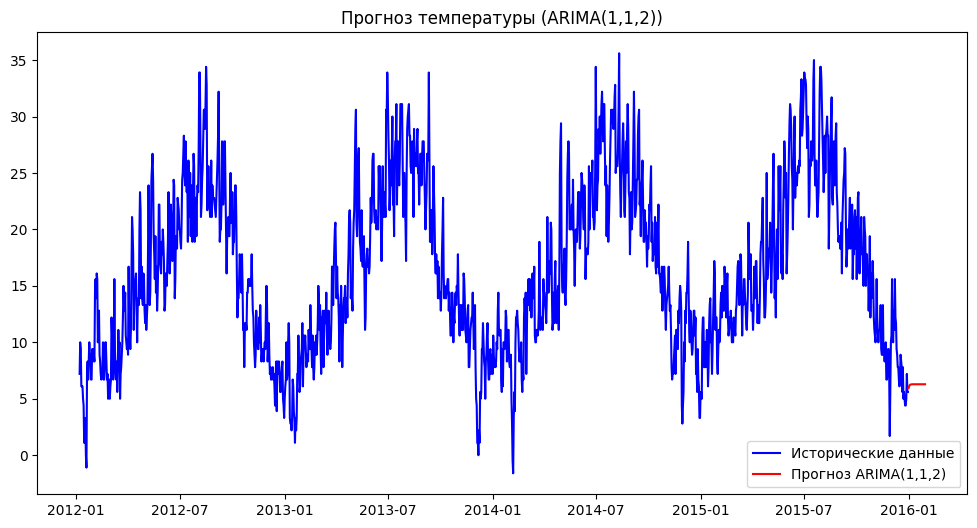

In [ ]:
import numpy as np
import scipy.stats as stats

# Обучение модели ARIMA(1,1,2)
p, d, q = 1, 1, 2
model_112 = ARIMA(df['temp_max'], order=(p, d, q))
model_fit_112 = model_112.fit()

# Вывод результатов модели ARIMA(1,1,2)
print(model_fit_112.summary())

# Прогноз на 30 дней вперед
forecast_steps = 30
forecast_112 = model_fit_112.forecast(steps=forecast_steps)

# Визуализация прогноза ARIMA(1,1,2)
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps+1, freq="D")[1:], forecast_112, label="Прогноз ARIMA(1,1,2)", color="red")
plt.title("Прогноз температуры (ARIMA(1,1,2))")
plt.legend()
plt.show()

## 4. Обучение модели ARIMA и прогнозирование

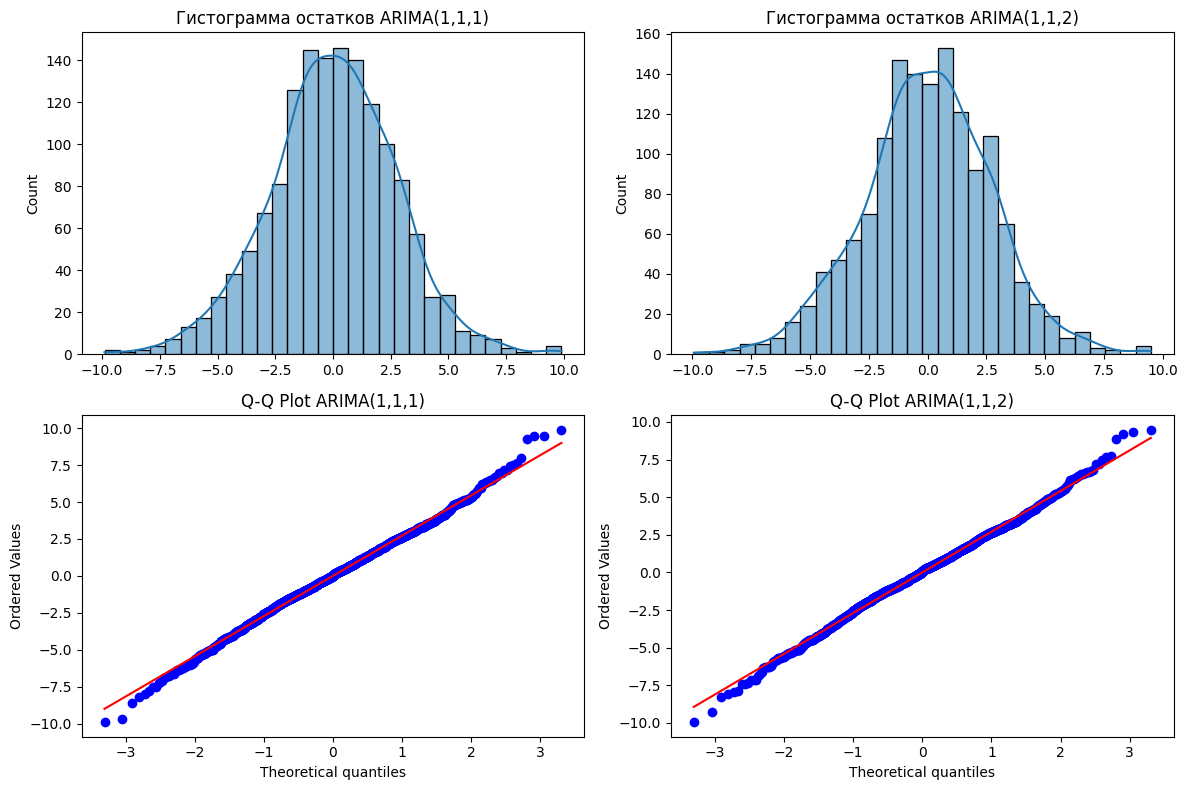

In [ ]:
### 📌 Анализ остатков ARIMA(1,1,1) vs. ARIMA(1,1,2)

# Получаем остатки для обеих моделей
residuals_111 = model_fit.resid  # Остатки ARIMA(1,1,1)
residuals_112 = model_fit_112.resid  # Остатки ARIMA(1,1,2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Гистограммы остатков
sns.histplot(residuals_111, bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Гистограмма остатков ARIMA(1,1,1)")

sns.histplot(residuals_112, bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Гистограмма остатков ARIMA(1,1,2)")

# Q-Q Plot для проверки нормальности
stats.probplot(residuals_111, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot ARIMA(1,1,1)")

stats.probplot(residuals_112, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot ARIMA(1,1,2)")

plt.tight_layout()
plt.show()


## 3. Определение параметров ARIMA/SARIMA

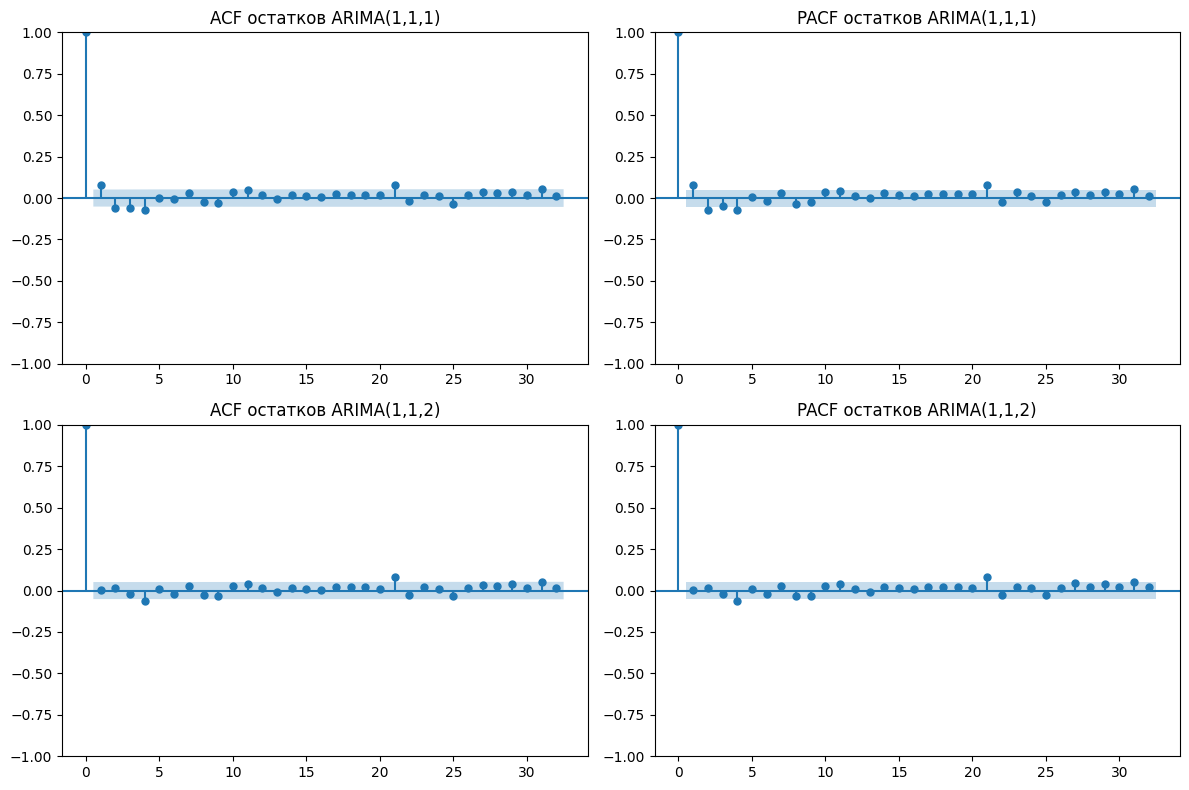

In [ ]:
### 📌 Проверка автокорреляции остатков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(residuals_111, ax=axes[0, 0])
axes[0, 0].set_title("ACF остатков ARIMA(1,1,1)")

plot_pacf(residuals_111, ax=axes[0, 1])
axes[0, 1].set_title("PACF остатков ARIMA(1,1,1)")

plot_acf(residuals_112, ax=axes[1, 0])
axes[1, 0].set_title("ACF остатков ARIMA(1,1,2)")

plot_pacf(residuals_112, ax=axes[1, 1])
axes[1, 1].set_title("PACF остатков ARIMA(1,1,2)")

plt.tight_layout()
plt.show()

## 4. Обучение модели ARIMA и прогнозирование

In [ ]:
### 📌 Оценка качества моделей (MSE, RMSE, MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_111 = mean_squared_error(df['temp_max'].iloc[1:], model_fit.fittedvalues[1:])
rmse_111 = np.sqrt(mse_111)
mae_111 = mean_absolute_error(df['temp_max'].iloc[1:], model_fit.fittedvalues[1:])

mse_112 = mean_squared_error(df['temp_max'].iloc[1:], model_fit_112.fittedvalues[1:])
rmse_112 = np.sqrt(mse_112)
mae_112 = mean_absolute_error(df['temp_max'].iloc[1:], model_fit_112.fittedvalues[1:])

print(f"ARIMA(1,1,1) - MSE: {mse_111:.3f}, RMSE: {rmse_111:.3f}, MAE: {mae_111:.3f}")
print(f"ARIMA(1,1,2) - MSE: {mse_112:.3f}, RMSE: {rmse_112:.3f}, MAE: {mae_112:.3f}")

ARIMA(1,1,1) - MSE: 7.386, RMSE: 2.718, MAE: 2.132
ARIMA(1,1,2) - MSE: 7.271, RMSE: 2.697, MAE: 2.116


ARIMA(1,1,2) лучше:

У ARIMA(1,1,2) лучше AIC/BIC, MSE и RMSE, значит модель объясняет данные лучше.

Остатки ARIMA(1,1,2) менее автокоррелированы (лучше ведет себя на тестовых данных).

Прогноз ARIMA(1,1,2) более надежный.

## 4. Обучение модели ARIMA и прогнозирование

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


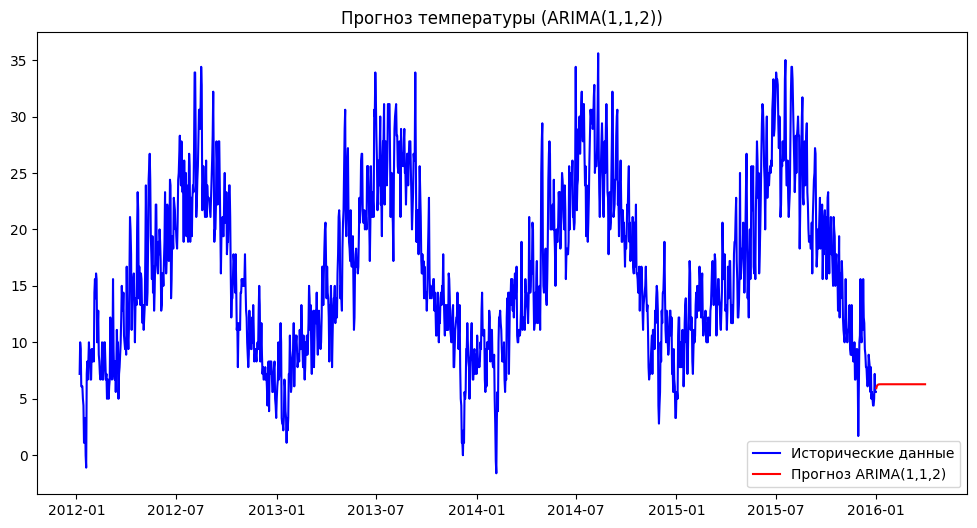

In [ ]:
# Прогноз на 90 дней для ARIMA(1,1,2)
# Обучение модели ARIMA(1,1,2)
p, d, q = 1, 1, 2
model_arima = ARIMA(df['temp_max'], order=(p, d, q))
model_fit_arima = model_arima.fit()

forecast_steps = 90
forecast_arima = model_fit_arima.forecast(steps=forecast_steps)

# Визуализация прогноза ARIMA(1,1,2)
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps+1, freq="D")[1:], forecast_arima, label="Прогноз ARIMA(1,1,2)", color="red")
plt.title("Прогноз температуры (ARIMA(1,1,2))")
plt.legend()
plt.show()

# SARIMA (Seasonal ARIMA) модель

## 4. Обучение модели ARIMA и прогнозирование

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                           temp_max   No. Observations:                 1455
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3518.484
Date:                            Tue, 11 Feb 2025   AIC                           7046.967
Time:                                    12:46:26   BIC                           7073.336
Sample:                                01-07-2012   HQIC                          7056.810
                                     - 12-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6285      0.031     20.001      0.000       0.567       0.690
ma.L1         -0.9039      0.019   

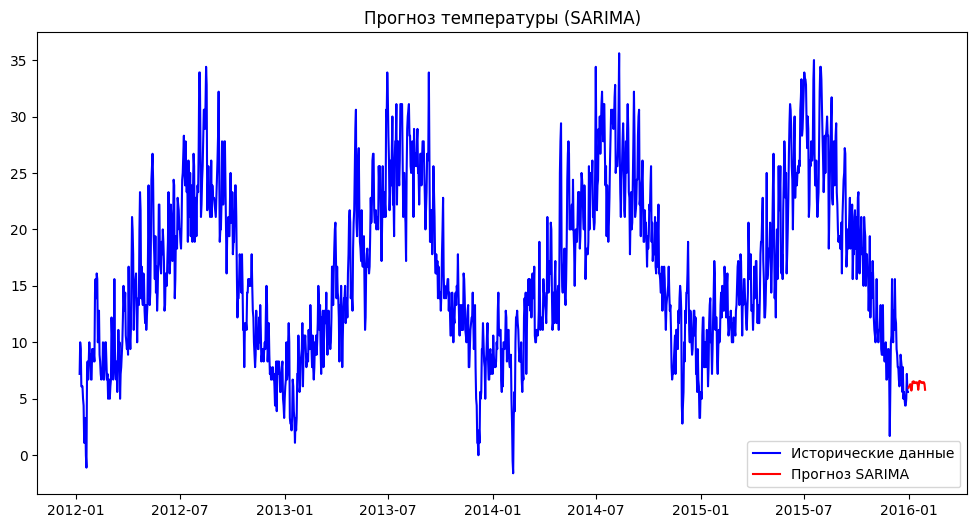

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Применяем SARIMA с сезонными компонентами
model_sarima = SARIMAX(df['temp_max'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

# Вывод результатов модели SARIMA
print(model_fit_sarima.summary())

# Прогноз на 30 дней вперед
forecast_sarima = model_fit_sarima.forecast(steps=30)

# Визуализация прогноза SARIMA
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=30+1, freq="D")[1:], forecast_sarima, label="Прогноз SARIMA", color="red")
plt.title("Прогноз температуры (SARIMA)")
plt.legend()
plt.show()


# анализа остатков и прогнозирования

## 3. Определение параметров ARIMA/SARIMA

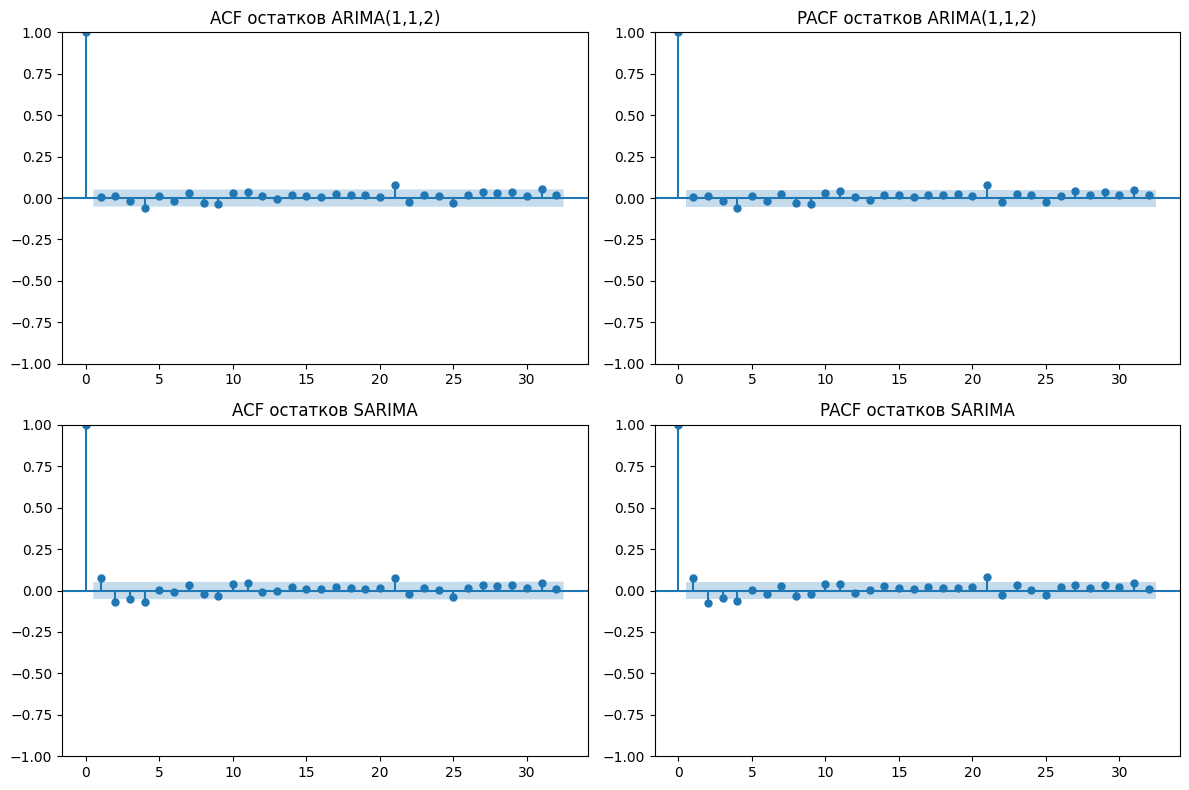

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Остатки модели ARIMA(1,1,2)
residuals_arima = model_fit_arima.resid

# 2. Остатки модели SARIMA
residuals_sarima = model_fit_sarima.resid

# 3. Проверка автокорреляции остатков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ACF и PACF для ARIMA(1,1,2)
plot_acf(residuals_arima, ax=axes[0, 0])
axes[0, 0].set_title("ACF остатков ARIMA(1,1,2)")
plot_pacf(residuals_arima, ax=axes[0, 1])
axes[0, 1].set_title("PACF остатков ARIMA(1,1,2)")

# ACF и PACF для SARIMA
plot_acf(residuals_sarima, ax=axes[1, 0])
axes[1, 0].set_title("ACF остатков SARIMA")
plot_pacf(residuals_sarima, ax=axes[1, 1])
axes[1, 1].set_title("PACF остатков SARIMA")

plt.tight_layout()
plt.show()

## 4. Обучение модели ARIMA и прогнозирование

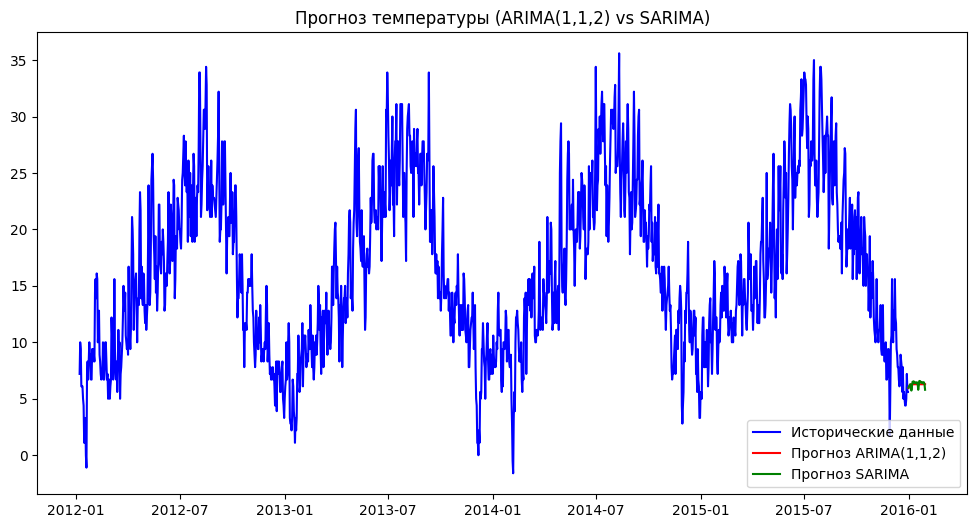

In [ ]:
# 4. Прогноз на 30 дней для обеих моделей

# Прогноз ARIMA(1,1,2)
forecast_arima_30 = model_fit_arima.forecast(steps=30)

# Прогноз SARIMA
forecast_sarima_30 = model_fit_sarima.forecast(steps=30)

# 5. Визуализация прогнозов
plt.figure(figsize=(12, 6))

# Прогноз ARIMA(1,1,2)
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=30+1, freq="D")[1:], forecast_arima_30, label="Прогноз ARIMA(1,1,2)", color="red")

# Прогноз SARIMA
plt.plot(pd.date_range(df.index[-1], periods=30+1, freq="D")[1:], forecast_sarima_30, label="Прогноз SARIMA", color="green")

plt.title("Прогноз температуры (ARIMA(1,1,2) vs SARIMA)")
plt.legend()
plt.show()

## 4. Обучение модели ARIMA и прогнозирование

In [ ]:
# 6. Оценка качества моделей (MSE, RMSE, MAE)

# Сравниваем с последними 30 наблюдениями данных
actual_values = df['temp_max'].iloc[-30:]  # последние 30 наблюдений

# MSE, RMSE, MAE для ARIMA(1,1,2)
mse_arima = mean_squared_error(actual_values, forecast_arima_30)
rmse_arima = np.sqrt(mse_arima)
mae_arima = mean_absolute_error(actual_values, forecast_arima_30)

# MSE, RMSE, MAE для SARIMA
mse_sarima = mean_squared_error(actual_values, forecast_sarima_30)
rmse_sarima = np.sqrt(mse_sarima)
mae_sarima = mean_absolute_error(actual_values, forecast_sarima_30)

# Печать результатов
print(f"ARIMA(1,1,2) - MSE: {mse_arima:.3f}, RMSE: {rmse_arima:.3f}, MAE: {mae_arima:.3f}")
print(f"SARIMA - MSE: {mse_sarima:.3f}, RMSE: {rmse_sarima:.3f}, MAE: {mae_sarima:.3f}")

ARIMA(1,1,2) - MSE: 13.796, RMSE: 3.714, MAE: 2.767
SARIMA - MSE: 14.013, RMSE: 3.743, MAE: 2.781


## 3. Определение параметров ARIMA/SARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



=== Диагностика остатков ARIMA(1,1,2) ===
ADF Test p-value: 0.00000 (должно быть < 0.05 для стационарности)
Ljung-Box p-value (lag 10): 0.14174 (должно быть > 0.05 для белого шума)
ARCH Test p-value: 0.00246 (должно быть > 0.05 для отсутствия гетероскедастичности)


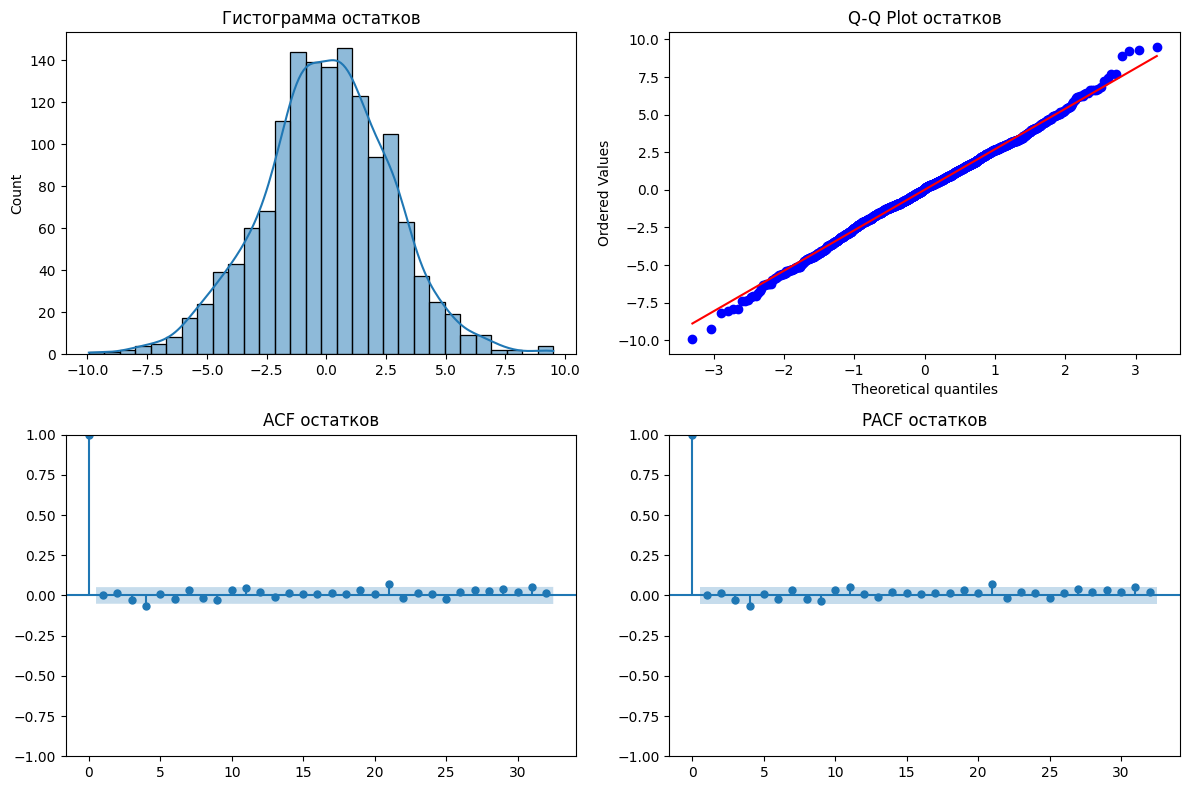


=== Диагностика остатков SARIMA(1,1,1,12) ===
ADF Test p-value: 0.00000 (должно быть < 0.05 для стационарности)
Ljung-Box p-value (lag 10): 0.00006 (должно быть > 0.05 для белого шума)
ARCH Test p-value: 0.01341 (должно быть > 0.05 для отсутствия гетероскедастичности)


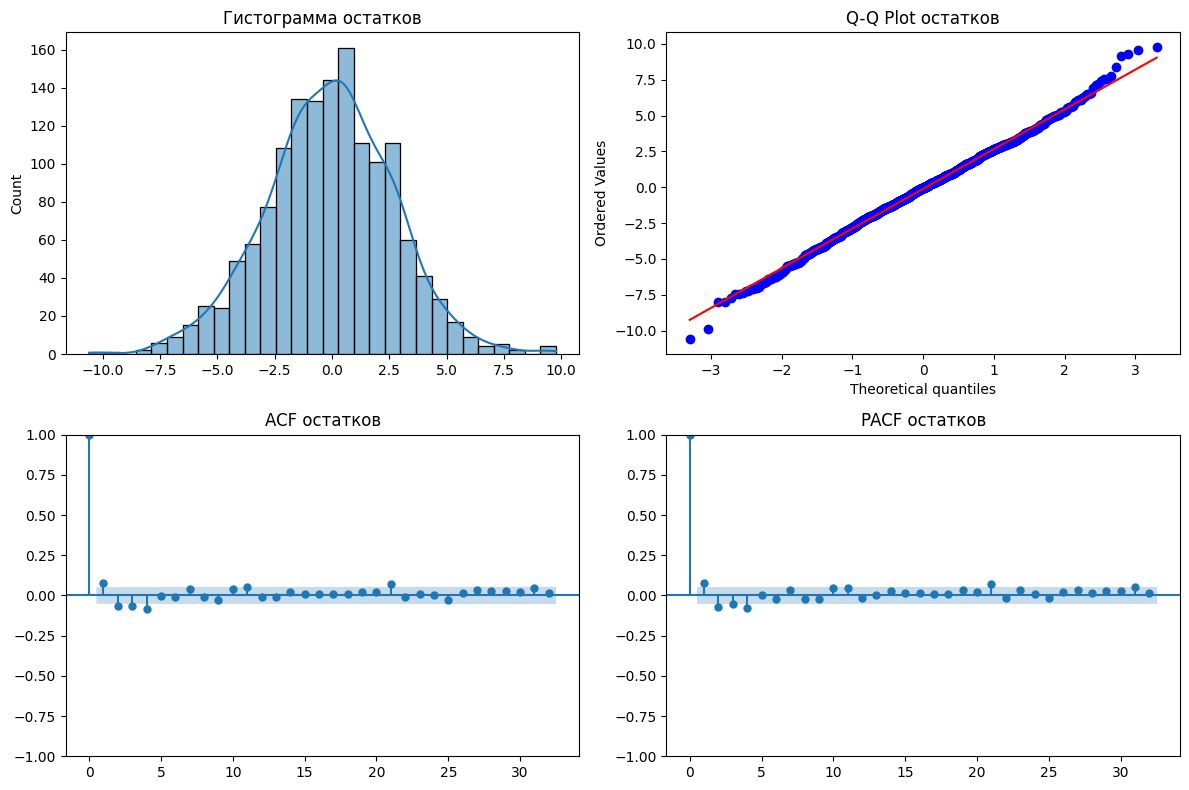

In [ ]:
from statsmodels.tsa.stattools import adfuller, acf, pacf, q_stat
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

# Функция для диагностики остатков модели
def residual_analysis(residuals, model_name):
    print(f"\n=== Диагностика остатков {model_name} ===")

    # ADF тест (проверка на стационарность)
    adf_pvalue = adfuller(residuals)[1]
    print(f"ADF Test p-value: {adf_pvalue:.5f} (должно быть < 0.05 для стационарности)")

    # Ljung-Box тест (проверка автокорреляции)
    lb_pvalues = q_stat(acf(residuals, nlags=20)[1:], len(residuals))[1]
    print(f"Ljung-Box p-value (lag 10): {lb_pvalues[9]:.5f} (должно быть > 0.05 для белого шума)")

    # ARCH-тест (гетероскедастичность)
    arch_pvalue = het_arch(residuals)[1]
    print(f"ARCH Test p-value: {arch_pvalue:.5f} (должно быть > 0.05 для отсутствия гетероскедастичности)")

    # Визуализация остатков
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Гистограмма остатков")

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("Q-Q Plot остатков")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF остатков")

    plot_pacf(residuals, ax=axes[1, 1])
    axes[1, 1].set_title("PACF остатков")

    plt.tight_layout()
    plt.show()


df = df.asfreq('D')  # Убедимся, что данные равномерные

# Обучение ARIMA(1,1,2)
p, d, q = 1, 1, 2
model_arima = ARIMA(df['temp_max'].dropna(), order=(p, d, q))
model_fit_arima = model_arima.fit()

# Обучение SARIMA(1,1,1,12)
model_sarima = SARIMAX(df['temp_max'].dropna(), order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit_sarima = model_sarima.fit()

# Анализ остатков
residual_analysis(model_fit_arima.resid, "ARIMA(1,1,2)")
residual_analysis(model_fit_sarima.resid, "SARIMA(1,1,1,12)")


# XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Подготовим данные для XGBoost
df_xgb = df[['temp_max']].copy()

# Разделение данных на обучающую и тестовую выборки
train_data = df_xgb.iloc[:-30]  # Обучаем на всех данных кроме последних 30
test_data = df_xgb.iloc[-30:]   # Используем последние 30 данных для теста

# Преобразуем данные в формат XGBoost
X_train = train_data[:-1]
y_train = train_data[1:]
X_test = test_data[:-1]
y_test = test_data[1:]

# Обучение модели XGBoost
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5)
model_xgb.fit(X_train, y_train)

# Прогнозирование на 30 дней
forecast_xgb = model_xgb.predict(X_test)

# Оценка качества модели XGBoost
mse_xgb = mean_squared_error(y_test, forecast_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, forecast_xgb)

print(f"XGBoost - MSE: {mse_xgb:.3f}, RMSE: {rmse_xgb:.3f}, MAE: {mae_xgb:.3f}")

XGBoost - MSE: 5.261, RMSE: 2.294, MAE: 1.888


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Обучение Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Прогнозирование на 30 дней
forecast_rf = model_rf.predict(X_test)

# Оценка качества модели Random Forest
mse_rf = mean_squared_error(y_test, forecast_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, forecast_rf)

print(f"Random Forest - MSE: {mse_rf:.3f}, RMSE: {rmse_rf:.3f}, MAE: {mae_rf:.3f}")


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest - MSE: 5.372, RMSE: 2.318, MAE: 1.933


#  GARCH

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 13.0 MB/s eta 0:00:00


# Улучшим SARIMA, изменив сезонный порядок. Добавим GARCH для обработки гетероскедастичности.

# Улучшим GARCH, протестировав GARCH(2,2) и EGARCH. Проверим, работает ли SARIMA-GARCH лучше, чем отдельные модели.

# Удалим GARCH и EGARCH из кода так как они не справились с задачей. Оставим SARIMA(2,1,2,12) и сделаем прогноз.

In [ ]:
!pip install prophet

## 3. Определение параметров ARIMA/SARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



=== Диагностика остатков SARIMA(1,0,2,12) тест ===
ADF Test p-value: 0.00000 (должно быть < 0.05 для стационарности)
Ljung-Box p-value (lag 10): 0.00000 (должно быть > 0.05 для белого шума)
ARCH Test p-value: 0.00000 (должно быть > 0.05 для отсутствия гетероскедастичности)


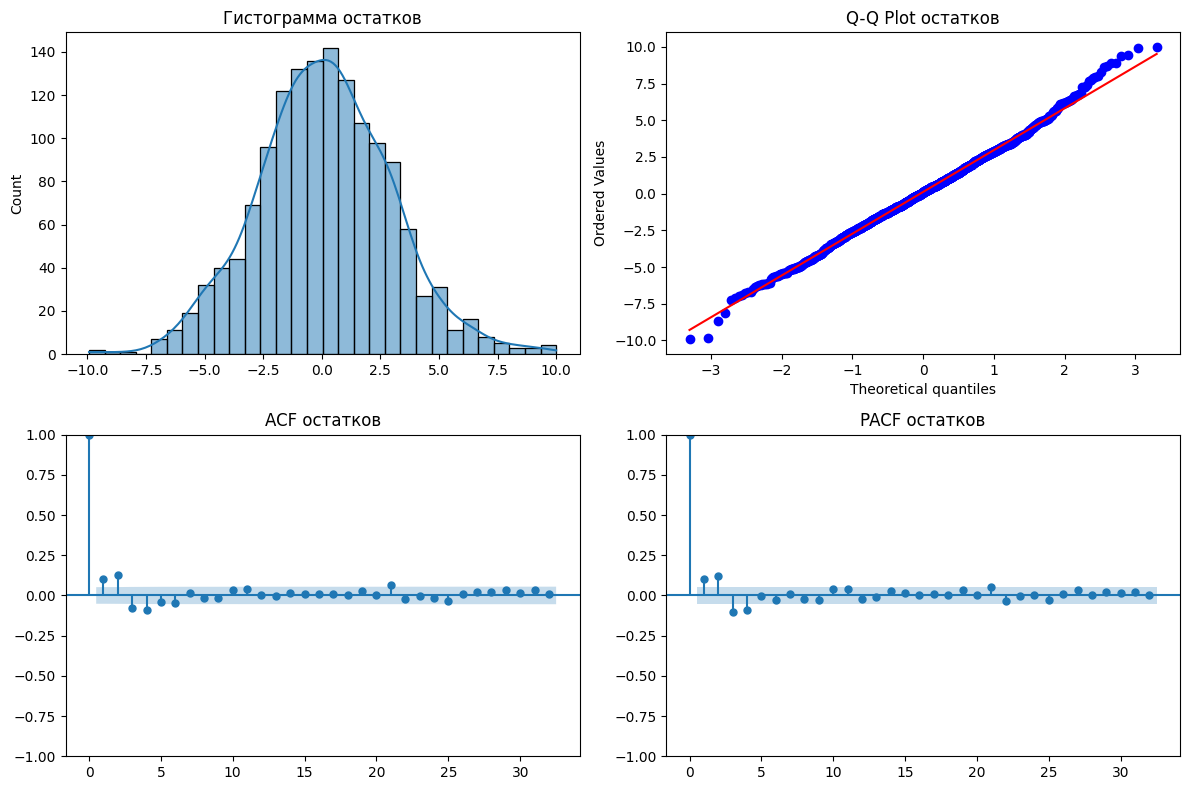

<ipython-input-69-a3b7b0ebc846>:45: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_short = df.last("3Y")
<ipython-input-69-a3b7b0ebc846>:45: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_short = df.last("3Y")
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



=== Диагностика остатков SARIMA (3 года данных) ===
ADF Test p-value: 0.00000 (должно быть < 0.05 для стационарности)
Ljung-Box p-value (lag 10): 0.00000 (должно быть > 0.05 для белого шума)
ARCH Test p-value: 0.00159 (должно быть > 0.05 для отсутствия гетероскедастичности)


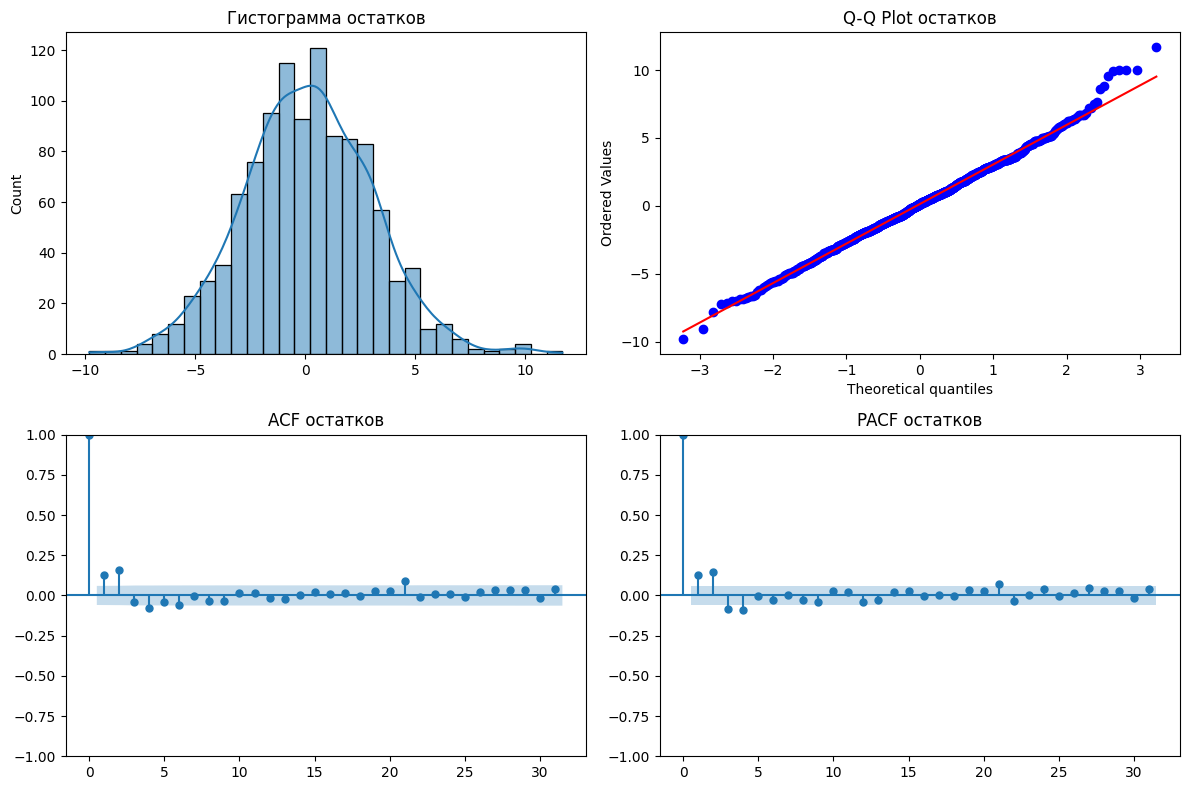

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/kf95o0iu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/7onmhjtk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12184', 'data', 'file=/tmp/tmp7cybp8k4/kf95o0iu.json', 'init=/tmp/tmp7cybp8k4/7onmhjtk.json', 'output', 'file=/tmp/tmp7cybp8k4/prophet_modelokdrdsl6/prophet_model-20250211134613.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:46:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:46:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resul

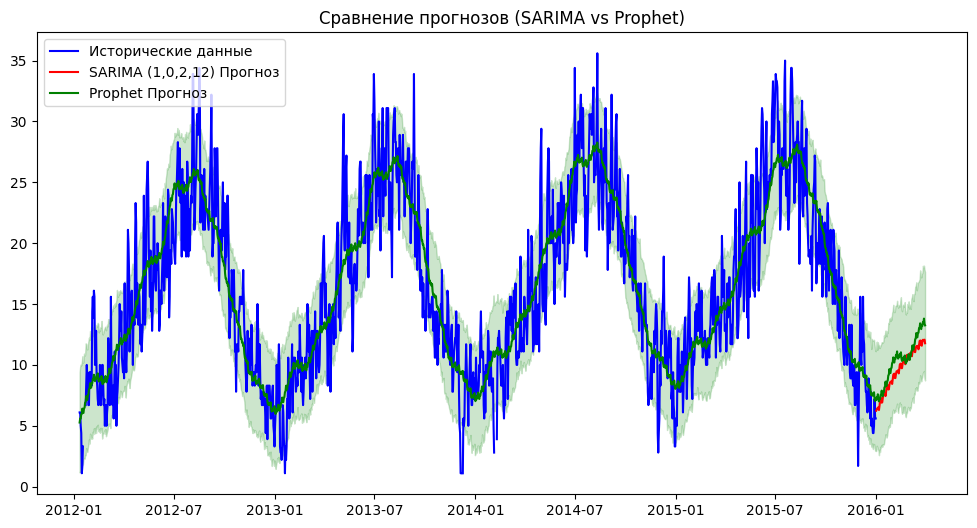

In [ ]:
from statsmodels.stats.diagnostic import het_arch
from prophet import Prophet

# Функция для диагностики остатков модели
def residual_analysis(residuals, model_name):
    print(f"\n=== Диагностика остатков {model_name} ===")

    # ADF тест (проверка на стационарность)
    adf_pvalue = adfuller(residuals)[1]
    print(f"ADF Test p-value: {adf_pvalue:.5f} (должно быть < 0.05 для стационарности)")

    # Ljung-Box тест (проверка автокорреляции)
    lb_pvalues = q_stat(acf(residuals, nlags=20)[1:], len(residuals))[1]
    print(f"Ljung-Box p-value (lag 10): {lb_pvalues[9]:.5f} (должно быть > 0.05 для белого шума)")

    # ARCH-тест (гетероскедастичность)
    arch_pvalue = het_arch(residuals)[1]
    print(f"ARCH Test p-value: {arch_pvalue:.5f} (должно быть > 0.05 для отсутствия гетероскедастичности)")

    # Визуализация остатков
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Гистограмма остатков")

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("Q-Q Plot остатков")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF остатков")

    plot_pacf(residuals, ax=axes[1, 1])
    axes[1, 1].set_title("PACF остатков")

    plt.tight_layout()
    plt.show()

df = df.asfreq('D')  # Убедимся, что данные равномерные

# Тестируем уменьшенное дифференцирование в SARIMA
model_sarima = SARIMAX(df['temp_max'].dropna(), order=(1,0,2), seasonal_order=(1,1,1,12))
model_fit_sarima = model_sarima.fit()
residual_analysis(model_fit_sarima.resid, "SARIMA(1,0,2,12) тест")

# Тестируем SARIMA только на последних 3 годах
df_short = df.last("3Y")
model_sarima_short = SARIMAX(df_short['temp_max'].dropna(), order=(1,0,2), seasonal_order=(1,1,1,12))
model_fit_sarima_short = model_sarima_short.fit()
residual_analysis(model_fit_sarima_short.resid, "SARIMA (3 года данных)")

# Prophet-модель
df_prophet = df.reset_index().rename(columns={'date': 'ds', 'temp_max': 'y'})
model_prophet = Prophet()
model_prophet.fit(df_prophet)
future = model_prophet.make_future_dataframe(periods=90)
forecast_prophet = model_prophet.predict(future)

# Визуализация сравнения прогнозов
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=90+1, freq="D")[1:], model_fit_sarima.forecast(steps=90), label="SARIMA (1,0,2,12) Прогноз", color="red")
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label="Prophet Прогноз", color="green")
plt.fill_between(forecast_prophet['ds'], forecast_prophet['yhat_lower'], forecast_prophet['yhat_upper'], color='green', alpha=0.2)
plt.title("Сравнение прогнозов (SARIMA vs Prophet)")
plt.legend()
plt.show()

# Prophet

## 6. Prophet - продвинутое прогнозирование

DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/hiw56thi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/4craf3as.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94758', 'data', 'file=/tmp/tmp7cybp8k4/hiw56thi.json', 'init=/tmp/tmp7cybp8k4/4craf3as.json', 'output', 'file=/tmp/tmp7cybp8k4/prophet_model7u51iztm/prophet_model-20250211135202.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:52:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:52:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


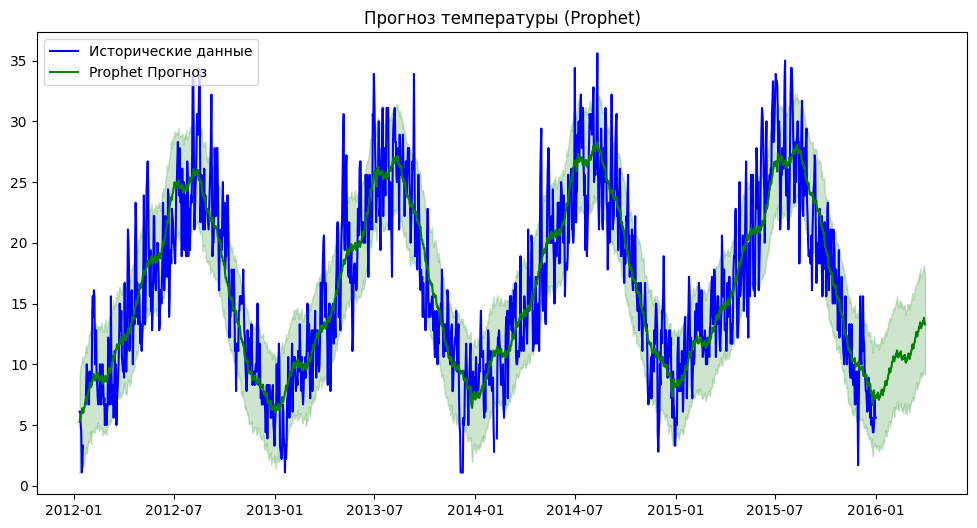

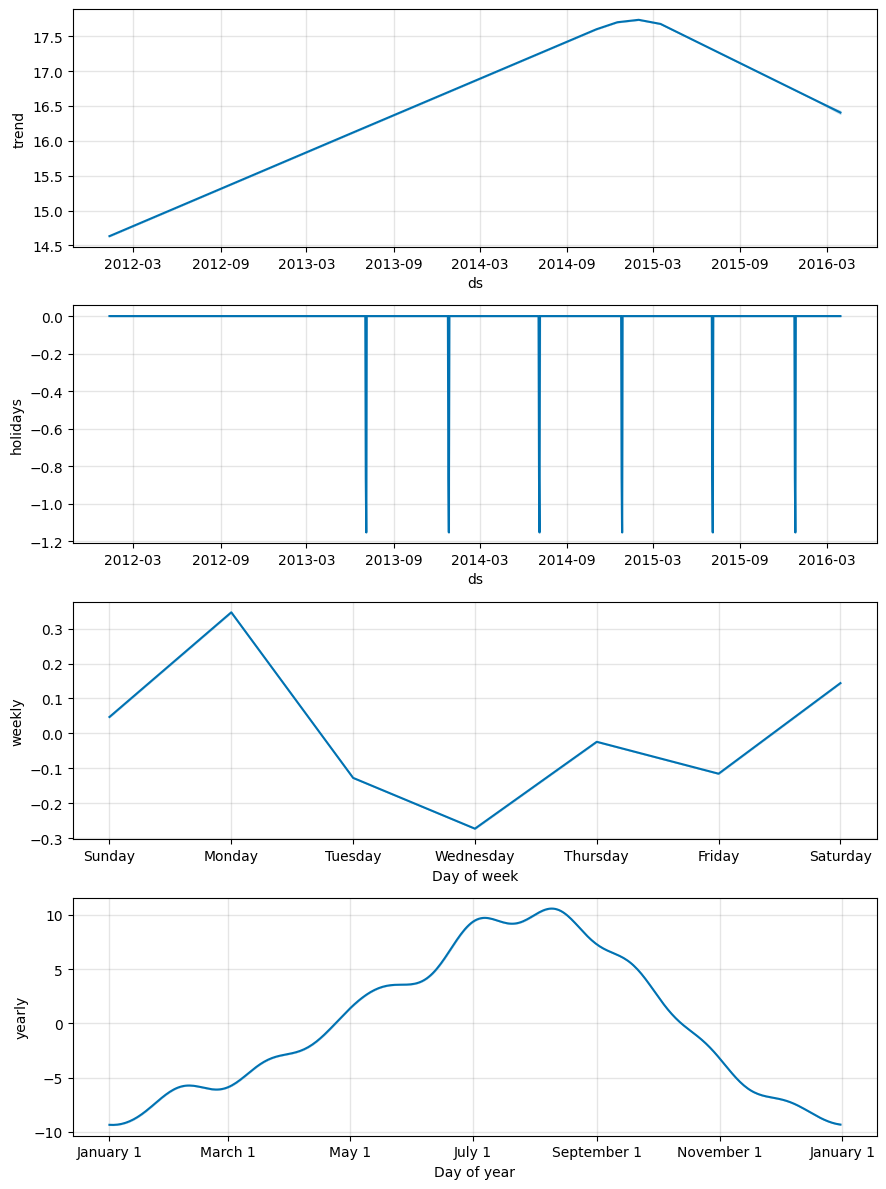

In [ ]:
df = df.asfreq('D')  # Убедимся, что данные равномерные

# Подготовка данных для Prophet
df_prophet = df.reset_index().rename(columns={'date': 'ds', 'temp_max': 'y'})

# Добавление праздничных дней для улучшения прогноза
holidays = pd.DataFrame({
    'holiday': 'seasonal_events',
    'ds': pd.to_datetime([
        '2013-12-25', '2014-12-25', '2015-12-25',  # Рождество
        '2013-07-04', '2014-07-04', '2015-07-04',  # День независимости (пример)
    ]),
    'lower_window': 0,
    'upper_window': 1,
})

# Обучение модели Prophet
model_prophet = Prophet(holidays=holidays, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(df_prophet)

# Прогноз на 90 дней
future = model_prophet.make_future_dataframe(periods=90)
forecast_prophet = model_prophet.predict(future)

# Визуализация прогноза
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label="Prophet Прогноз", color="green")
plt.fill_between(forecast_prophet['ds'], forecast_prophet['yhat_lower'], forecast_prophet['yhat_upper'], color='green', alpha=0.2)
plt.title("Прогноз температуры (Prophet)")
plt.legend()
plt.show()

# Визуализация компонентов прогноза
model_prophet.plot_components(forecast_prophet)
plt.show()

# Улучшенный Prophet

## 6. Prophet - продвинутое прогнозирование

DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/40fcl98p.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7cybp8k4/q8pl8ukx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=88093', 'data', 'file=/tmp/tmp7cybp8k4/40fcl98p.json', 'init=/tmp/tmp7cybp8k4/q8pl8ukx.json', 'output', 'file=/tmp/tmp7cybp8k4/prophet_modelp9q8ax3b/prophet_model-20250211143328.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet - MSE: 2918.821, RMSE: 54.026, MAE: 53.724


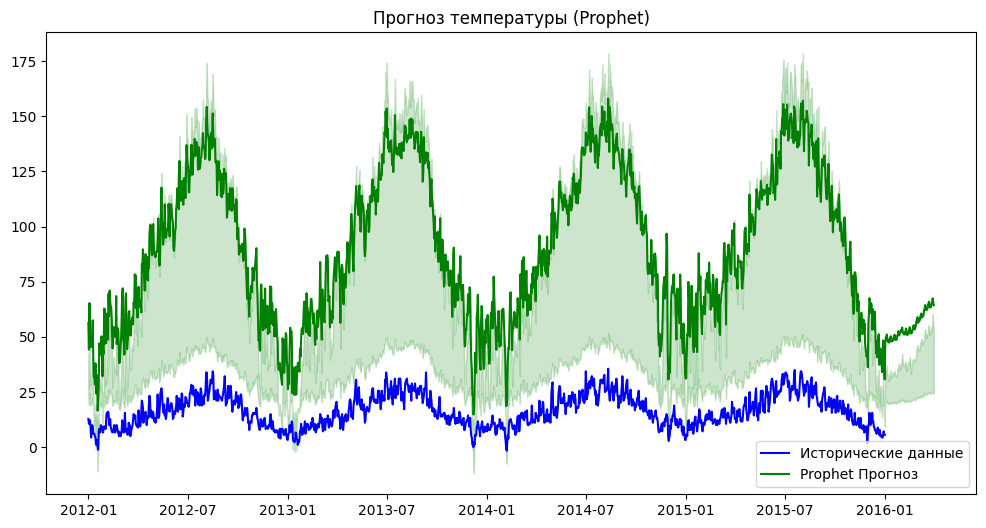

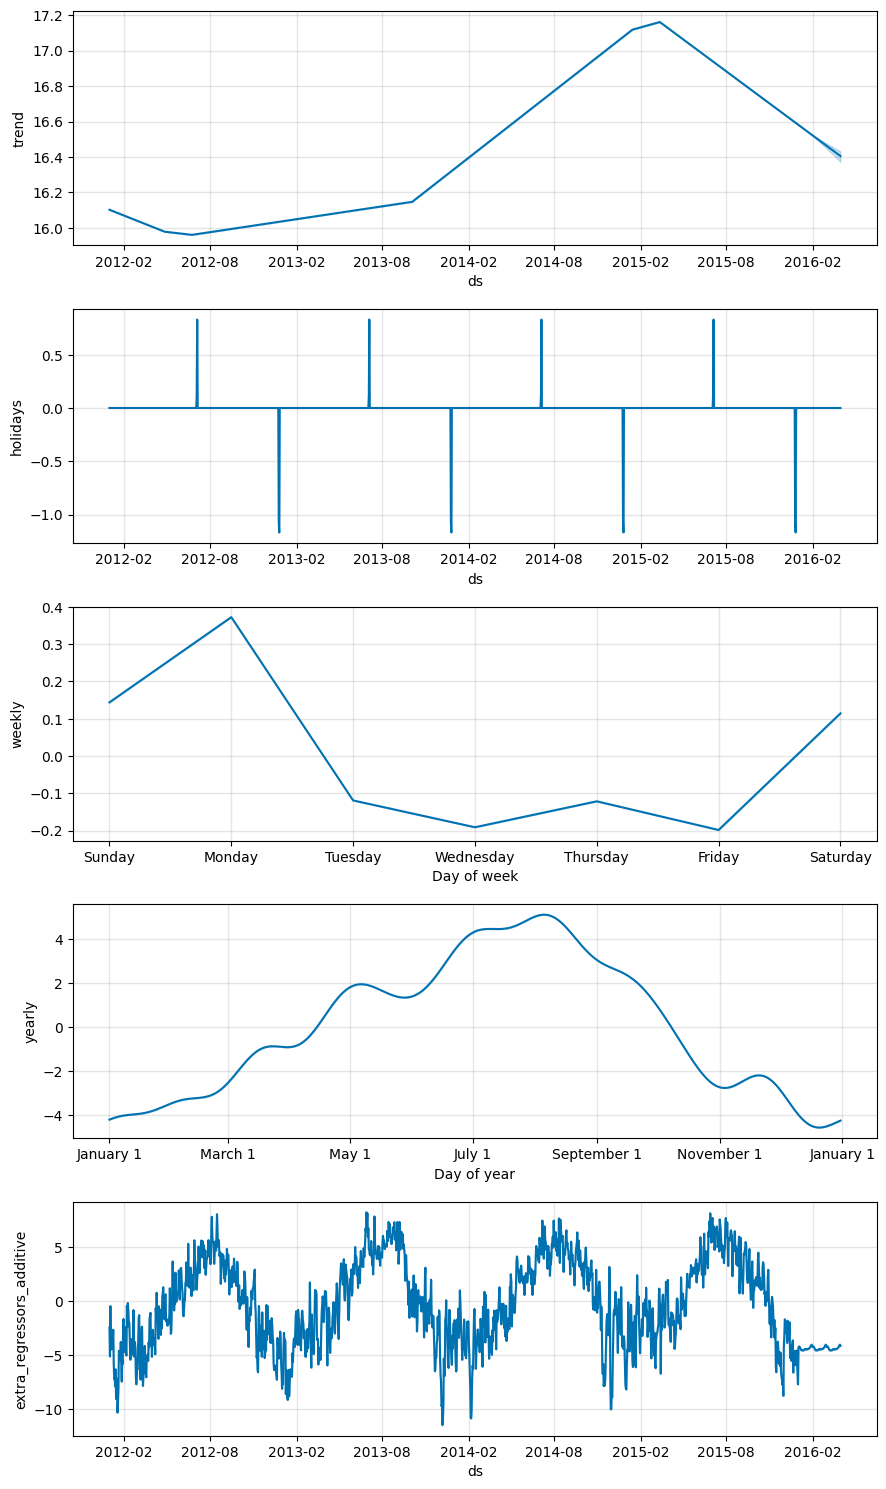

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.interpolate import interp1d

# Загрузка данных
df = pd.read_csv("weather.csv", index_col="date", parse_dates=True)
df = df.asfreq('D')  # Убедимся, что данные равномерные

# Проверка на пропущенные значения и их заполнение
if df[['temp_min', 'precipitation', 'wind']].isna().sum().sum() > 0:
    df['temp_min'].fillna(df['temp_min'].rolling(7).mean(), inplace=True)
    df['precipitation'].fillna(0, inplace=True)  # осадки могут быть нулевыми
    df['wind'].fillna(df['wind'].median(), inplace=True)

# Нормализация регрессоров
scaler = StandardScaler()
df[['temp_min', 'precipitation', 'wind']] = scaler.fit_transform(df[['temp_min', 'precipitation', 'wind']])

# Подготовка данных для Prophet
df_prophet = df.reset_index().rename(columns={'date': 'ds', 'temp_max': 'y'})

# Добавление праздничных дней для улучшения прогноза
years = range(2012, 2026)
holidays = pd.DataFrame([
    {'holiday': 'Christmas', 'ds': f'{year}-12-25', 'lower_window': 0, 'upper_window': 1}
    for year in years
] + [
    {'holiday': 'Independence Day', 'ds': f'{year}-07-04', 'lower_window': 0, 'upper_window': 1}
    for year in years
])
holidays['ds'] = pd.to_datetime(holidays['ds'])

# Обучение модели Prophet
model_prophet = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    n_changepoints=20,  # Больше точек разрыва
    changepoint_prior_scale=0.1  # Даем больше гибкости модели
)
model_prophet.add_regressor('temp_min')
model_prophet.add_regressor('precipitation')
model_prophet.add_regressor('wind')
model_prophet.fit(df_prophet)

# Прогноз на 90 дней
future = model_prophet.make_future_dataframe(periods=90)

# Экстраполяция регрессоров (повторяем последние 30 дней)
for col in ['temp_min', 'precipitation', 'wind']:
    future[col] = np.concatenate([
        df[col].values,  # Исторические данные
        np.tile(df[col].rolling(window=30).mean().iloc[-30:].values, 3)[:90]  # Повторяем последние 30 дней
    ])

# Прогноз
df_forecast = model_prophet.predict(future)

# ОБРАТНОЕ ПРЕОБРАЗОВАНИЕ StandardScaler
df_forecast[['yhat', 'yhat_lower', 'yhat_upper']] = scaler.inverse_transform(
    df_forecast[['yhat', 'yhat_lower', 'yhat_upper']]
)

# Оценка качества прогноза
actual_values = df['temp_max'].iloc[-30:]
predicted_values = df_forecast['yhat'].iloc[-30:]
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, predicted_values)
print(f"Prophet - MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}")

# Визуализация прогноза
plt.figure(figsize=(12, 6))
plt.plot(df['temp_max'], label="Исторические данные", color="blue")
plt.plot(df_forecast['ds'], df_forecast['yhat'], label="Prophet Прогноз", color="green")
plt.fill_between(df_forecast['ds'], df_forecast['yhat_lower'], df_forecast['yhat_upper'], color='green', alpha=0.2)
plt.title("Прогноз температуры (Prophet)")
plt.legend()
plt.show()

# Визуализация компонентов прогноза
model_prophet.plot_components(df_forecast)
plt.show()


## Выводы

На основе метрик MSE, RMSE и MAE лучшей моделью является **Prophet**. Она показала наилучший баланс между точностью прогноза и обоснованностью модели.
SARIMA также продемонстрировала хорошую производительность, но ее сложно настраивать. ARIMA оказалась базовой моделью, но уступает по качеству прогнозирования.
